In [ ]:
# DOESN'T WORK!!!!

In [1]:
atomstring = '''
Fe -0.64147387529051 0.51990405379180 0.11450483185168
O 0.33915564253394 2.18819453520299 -0.84159903476570
H 0.65823736209818 2.99799985286513 -0.40575899522591
O -1.29914529040912 -0.20924466129350 -1.80322550106302
H -2.11419692217693 0.03267722517314 -2.27701147100162
O 0.01237770373627 1.24396717111997 2.03533113813669
H 0.83097217272839 1.00756306178418 2.50577204385612
O -1.62284672685044 -1.15048542622041 1.07007991103536
H -1.94592790838151 -1.95766677806096 0.63237073377438
O -2.41866907277644 1.66373032346654 0.25658821238371
H -2.55381601393967 2.56024091790599 -0.09930153080408
O 1.13404022498401 -0.62623224778001 -0.02436092147139
H 1.26370551457750 -1.52400168391753 0.33034524187694
H -3.28110369794222 1.35873477131317 0.59094893393907
H -0.81032015579443 -0.82248643308581 -2.37966496653734
H 1.99795010138314 -0.32692539271158 -0.36001715946551
H 0.57998322602479 2.26642229799559 -1.78148703231078
H -0.47668197075682 1.85673194452426 2.61208351578631
H -1.85653031374812 -1.23356353207299 2.011352050005
'''

In [2]:
import numpy as np
from pyscf import gto, scf, mp, cc

mol = gto.M(atom = atomstring,
            basis = {
                'default': 'ccpvdz-dk',
                'Fe': 'ccpwcvtz-dk'
                },
            verbose = 4,
            unit = 'angstrom',
            symmetry = 0,
            charge = 2,
            spin = 4,
            max_memory = 20000,
            )

mf = scf.UHF(mol).density_fit()
mf = mf.x2c()
dm0 = mf.from_chk('./hs_tdz_mf.chk')
mf.max_cycle = 100
mf.level_shift = 0.5
mf = mf.newton()
mf.kernel(dm0=dm0)

System: uname_result(system='Linux', node='sharmagroup-rn', release='7.0.0-29-generic', version='#29~24.04.2-Ubuntu SMP PREEMPT_DYNAMIC Wed Aug 12 17:25:56 UTC 2', machine='x86_64')  Threads 16
Python 3.12.13 | packaged by Anaconda, Inc. | (main, Mar 19 2026, 20:20:58) [GCC 14.3.0]
numpy 2.4.4  scipy 1.17.1  h5py 3.16.0
Date: Sat Aug 22 14:52:18 2026
PySCF version 2.14.0
PySCF path  /home/sharmagroup/sharmagroup/pyscf
GIT ORIG_HEAD 3d1768f5e33b144b606c3d2c81c12ee54d794501
GIT HEAD      c63a953ba603a5ad8c1d65d88da72aaf05ede4d8

[ENV] OLD_PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:
[ENV] PYSCF_EXT_PATH /home/sharmagroup/sharmagroup/pyscf-forge:/home/sharmagroup/sharmagroup/pyscf-forge:
[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 19
[INPUT] num. electrons = 84
[INPUT] charge = 2
[INPUT] spin (= nelec alpha-beta = 2S) = 4
[INPUT] symmetry 0 subgroup None
[INPUT] Mole.unit = angstrom
[INPUT] Symbol           X                Y                Z      unit   

np.float64(-1727.5438115926056)

In [3]:
mymp = mp.MP2(mf).set_frozen()
mymp.kernel()
print(mymp.e_corr)


******** <class 'pyscf.mp.dfump2.DFUMP2'> ********
nocc = (np.int64(33), np.int64(29)), nmo = (235, 235)
frozen orbitals 11
max_memory 20000 MB (current use 698 MB)
E(DFUMP2) = -1729.38153669197  E_corr = -1.83772509936827
E(SCS-DFUMP2) = -1729.2986611043  E_corr = -1.75484951169572
E_corr(same-spin) = -0.519716085630231
E_corr(oppo-spin) = -1.31800901373804
-1.8377250993682663


In [25]:
import os
from pyscf import lo
from pyscf.data import elements
from pyscf import lno
from afqmc.lno_afqmc import tools, lno_afqmc_test

def combine_orbitals(mf, mo_coeff1, mo_coeff2, torr=1e-6):
    mo_comb = np.hstack([mo_coeff1, mo_coeff2])   # redundant spanning set for the union
    print('Naive cLAS Size: ', mo_comb.shape[1])

    # svd combined orbitals
    s = mf.get_ovlp()                       # AO overlap, (nao, nao)
    G = mo_comb.T @ s @ mo_comb       # MO–MO Gram matrix, (n, n), symmetric PSD
    w, V = np.linalg.eigh(G)                # eigh == SVD for symmetric PSD
    w, V = w[::-1], V[:, ::-1]              # descending
    # tol  = 1e-10 * w[0]                      # relative threshold
    keep = w > torr
    rank = keep.sum()
    print(f"union dimension = {keep.sum()} of {len(w)}")
    # S-orthonormal orbitals spanning span(moa) ∪ span(mob)
    mo_comb = mo_comb @ (V[:, keep] / np.sqrt(w[keep]))
    assert np.allclose(mo_comb.T @ s @ mo_comb, np.eye(rank), atol=torr)
    print(f'Combine Orbital size: {mo_comb.shape[1]}')
    print(f'Lindep. singular value threshold: {torr}')
    print(f'Smallest retained singular value: {w[keep][-1]:.2e}')
    return mo_comb


def uiao_fragment2(mf, nfrozen, frag_type='atom', more_loc=None, minao='minao'):
    # IAO localization
    mol = mf.mol
    s1e = mf.get_ovlp()
    moliao = lo.iao.reference_mol(mol, minao)
    nocca = np.count_nonzero(mf.mo_occ[0])
    noccb = np.count_nonzero(mf.mo_occ[1])
    orbocc_a = mf.mo_coeff[0][:,nfrozen:nocca]
    orbocc_b = mf.mo_coeff[1][:,nfrozen:noccb]
    orbocc = combine_orbitals(mf, orbocc_a, orbocc_b, torr=1e-6)
    lo_coeff = lo.iao.iao(mol, orbocc, minao)
    lo_coeff = lo.orth.vec_lowdin(lo_coeff, s1e)

    if frag_type == 'atom':
        frag_atmlist = lno.tools.autofrag_atom(moliao, H2heavy=False)
    elif frag_type == 'h2heavy':
        frag_atmlist = lno.tools.autofrag_atom(moliao, H2heavy=True)
    else:
        raise ValueError(f'Unsupported fragment type {str(frag_type)}')

    if more_loc is None:
        lo_coeff = [lo_coeff, lo_coeff]
        frag_list = lno.tools.autofrag_iao(moliao, 'atom', frag_atmlist)
        frag_list = [[i,i] for i in frag_list]
    elif more_loc == 'boys':
        lo_coeff = lo.Boys(mol, lo_coeff).kernel()
        lo_coeff = lo.orth.vec_lowdin(lo_coeff, s1e)
        frag_list = lno.tools.map_lo_to_frag(mol, lo_coeff, frag_atmlist)
        lo_coeff = [lo_coeff, lo_coeff]
    elif more_loc == 'pm':
        lo_coeff = lo.PM(mol, lo_coeff).kernel()
        lo_coeff = lo.orth.vec_lowdin(lo_coeff, s1e)
        frag_list = lno.tools.map_lo_to_frag(mol, lo_coeff, frag_atmlist)
        lo_coeff = [lo_coeff, lo_coeff]
        frag_list = [[i,i] for i in frag_list]
    else:
        raise TypeError(f'Unsupported lo type {str(more_loc)}')

    frag_name = tools.name_fragments(frag_atmlist, moliao.elements, sep="")

    ortho_a = lo_coeff[0].conj().T @ s1e @ lo_coeff[0]
    ortho_b = lo_coeff[1].conj().T @ s1e @ lo_coeff[1]
    assert np.allclose(ortho_a, np.eye(ortho_a.shape[1]), atol=1e-8), \
        f"IAOs not orthonormal: max dev {np.abs(ortho_a - np.eye(ortho_a.shape[1])).max():.2e}"
    assert np.allclose(ortho_b, np.eye(ortho_b.shape[1]), atol=1e-8), \
        f"IAOs not orthonormal: max dev {np.abs(ortho_b - np.eye(ortho_b.shape[1])).max():.2e}"

    return lo_coeff, frag_list, frag_name

def iao_fragment(mf, nfrozen=None, frag_type='h2heavy', more_loc=None,
                 minao='minao', x2c=None, save2=None, read_from=None):
    """Build (or reuse) the IAO fragment input for an LNO calculation.

    save2     : path of an HDF5 file to write (lo_coeff, frag_list, frag_name) to.
    read_from : path of such a file to read instead of rebuilding the IAOs.
                The stored molecule must match `mf.mol`.
    """
    mol = mf.mol

    want = 'unrestricted' if isinstance(mf, scf.uhf.UHF) else 'restricted'

    if read_from is not None:
        if not os.path.isfile(read_from):
            raise FileNotFoundError(
                f'IAO fragment file {read_from} not found. Run the calculation '
                'once with save2=<file> to create it.')
        print(f'Reading IAO fragments from {read_from}')
        lo_coeff, frag_list, frag_name, meta = tools.load_iao_fragment(
            read_from, mol=mol, s1e=mf.get_ovlp())

        kind = tools._iao_spin_kind(lo_coeff)
        if kind != want:
            raise ValueError(f'{read_from} holds {kind} IAOs but {type(mf).__name__} '
                             f'needs {want} ones')
        for key, val in (('frag_type', frag_type), ('more_loc', more_loc)):
            if key in meta and meta[key] != str(val):
                print(f'Warning: {read_from} was built with {key}={meta[key]}, '
                      f'but {key}={val} was requested. Using the stored fragments.')

        print(f'Loaded {len(frag_name)} IAO fragments: {frag_name}')

        if save2 is not None and os.path.abspath(save2) != os.path.abspath(read_from):
            tools.save_iao_fragment(save2, lo_coeff, frag_list, frag_name, mol=mol, meta=meta)
            print(f'IAO fragments copied to {save2}')

        return lo_coeff, frag_list, frag_name

    if nfrozen is None:
        nfrozen = elements.chemcore(mol)

    if not tools._is_ccpvxz_family(mol.basis):
        print('Detected basis set not in the cc-pVXZ family. '
              'Run free atom scf to generate reference basis.')
        if x2c is None:
            x2c = tools._is_relativistic_basis(mol.basis)
        if x2c:
            print('Detected relativistic basis set. '
                  'Run free atom scf with scalar relativistic (sfX2C1e) effects.')
        minao = tools.free_atom_minao(mol, occ_tol=1e-6, sv_tol=1e-8, x2c=x2c)

    if isinstance(mf, scf.rhf.RHF):
        lo_coeff, frag_list, frag_name = \
            tools.riao_fragment(mf, nfrozen, frag_type, more_loc, minao)
    elif isinstance(mf, scf.uhf.UHF):
        lo_coeff, frag_list, frag_name = \
            uiao_fragment2(mf, nfrozen, frag_type, more_loc, minao)
    else:
        raise TypeError(f'Unsupported mf type {type(mf)}')

    if save2 is not None:
        meta = {'frag_type': frag_type,
                'more_loc': more_loc,
                'nfrozen': nfrozen,
                'minao': minao if isinstance(minao, str) else 'free_atom_minao'}
        tools.save_iao_fragment(save2, lo_coeff, frag_list, frag_name, mol=mol, meta=meta)
        print(f'IAO fragments saved to {save2}')

    return lo_coeff, frag_list, frag_name

In [27]:
mol = mf.mol
s1e = mf.get_ovlp()
nfrozen = elements.chemcore(mol)
nocca = np.count_nonzero(mf.mo_occ[0])
noccb = np.count_nonzero(mf.mo_occ[1])
orbocca = mf.mo_coeff[0][:,nfrozen:nocca]
orboccb = mf.mo_coeff[1][:,nfrozen:noccb]
orbocc = combine_orbitals(mf, orbocca, orboccb, torr=1e-6)

Naive cLAS Size:  62
union dimension = 50 of 62
Combine Orbital size: 50
Lindep. singular value threshold: 1e-06
Smallest retained singular value: 1.12e-06


In [28]:
print(tools.mo_span(orbocc, s1e, orbocca))
print(tools.mo_span(orbocc, s1e, orboccb))

(np.float64(4.1052258792362295e-07), np.float64(0.9999994388904472))
(np.float64(4.138175759837992e-07), np.float64(1.000000000000002))


In [29]:
lo_coeff, frag_list, frag_name = iao_fragment(
        mf,
        frag_type='h2heavy',
        more_loc='pm',
        save2=None,
        read_from=None,
        )

Detected basis set not in the cc-pVXZ family. Run free atom scf to generate reference basis.
Detected relativistic basis set. Run free atom scf with scalar relativistic (sfX2C1e) effects.
Naive cLAS Size:  62
union dimension = 50 of 62
Combine Orbital size: 50
Lindep. singular value threshold: 1e-06
Smallest retained singular value: 1.12e-06


******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
algorithm = ciah
pop_method = meta_lowdin
exponent = 2
Set conv_tol_grad to 0.000316228
Init f(x)= 40.773957512322  |g|= 2.2174
macro= 1  f(x)= 42.039231974273  delta_f= 1.26527  |g|= 1.43134  4 KF 20 Hx
macro= 2  f(x)= 42.956563243219  delta_f= 0.917331  |g|= 0.801686  4 KF 20 Hx
macro= 3  f(x)= 43.397630370359

In [30]:
print(tools.mo_span(lo_coeff[0], s1e, orbocca))
print(tools.mo_span(lo_coeff[1], s1e, orboccb))

(np.float64(4.105113963204232e-07), np.float64(0.9999994574387799))
(np.float64(4.1381250059924213e-07), np.float64(0.9999999431225491))


In [31]:
options = {
           'eql_time': 40,
           'n_blocks': 50,
           'n_walkers': 100,
           'mix_precision': True,
           'max_memory': 300000,
           'seed': 17,
           'walker_type': 'uhf',
           'trial': 'upt2ccsd',
           }


In [33]:
lo_coeff, frag_list, frag_name = iao_fragment(
        mf,
        frag_type='h2heavy',
        more_loc='pm',
        save2=None,
        read_from=None,
        )

threshs = [1e-4, 3e-5, 1e-5, 3e-6, 1e-6]
emp1 = np.zeros(len(threshs))
size1 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):
#     lno_thresh = [lno_thresh, lno_thresh]
    emp1[i], _, _, _, size1[i] \
        = lno_afqmc_test.run_afqmc(
                mf,
                lo_coeff,
                frag_list,
                frag_name,
                lno_thresh = lno_thresh,
                qmc_options = options,
                chol_cut = 1e-5,
                target_qmc_err = 5e-4,
                run_frag = None,
                nfrozen = None,
                run_mp = True,
                run_cc = False,
                run_qmc = False,
                plot_las = False,
                )



Detected basis set not in the cc-pVXZ family. Run free atom scf to generate reference basis.
Detected relativistic basis set. Run free atom scf with scalar relativistic (sfX2C1e) effects.
Naive cLAS Size:  62
union dimension = 50 of 62
Combine Orbital size: 50
Lindep. singular value threshold: 1e-06
Smallest retained singular value: 1.12e-06


******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
algorithm = ciah
pop_method = meta_lowdin
exponent = 2
Set conv_tol_grad to 0.000316228
Init f(x)= 40.773931666397  |g|= 2.21741
macro= 1  f(x)= 42.039242807609  delta_f= 1.26531  |g|= 1.43133  4 KF 20 Hx
macro= 2  f(x)= 42.955276308327  delta_f= 0.916034  |g|= 0.803635  4 KF 20 Hx
macro= 3  f(x)= 43.40216994110

In [34]:
lo_coeff, frag_list, frag_name = tools.iao_fragment(
        mf,
        frag_type='h2heavy',
        more_loc='pm',
        save2=None,
        read_from=None,
        )

emp2 = np.zeros(len(threshs))
size2 = np.zeros(len(threshs))

for i, lno_thresh in enumerate(threshs):

    emp2[i], _, _, _, size2[i] \
        = lno_afqmc_test.run_afqmc(
                mf,
                lo_coeff,
                frag_list,
                frag_name,
                lno_thresh = lno_thresh,
                qmc_options = options,
                chol_cut = 1e-5,
                target_qmc_err = 5e-4,
                run_frag = None,
                nfrozen = None,
                run_mp = True,
                run_cc = False,
                run_qmc = False,
                plot_las = False,
                )

Detected basis set not in the cc-pVXZ family. Run free atom scf to generate reference basis.
Detected relativistic basis set. Run free atom scf with scalar relativistic (sfX2C1e) effects.


******** <class 'pyscf.lo.pipek.PipekMezey'> ********
conv_tol = 1e-06
conv_tol_grad = None
max_cycle = 100
max_stepsize = 0.05
max_iters = 20
kf_interval = 5
kf_trust_region = 5
ah_start_tol = 1000000000.0
ah_start_cycle = 1
ah_level_shift = 0
ah_conv_tol = 1e-12
ah_lindep = 1e-14
ah_max_cycle = 40
ah_trust_region = 3
init_guess = atomic
algorithm = ciah
pop_method = meta_lowdin
exponent = 2
Set conv_tol_grad to 0.000316228
Init f(x)= 55.006798560655  |g|= 0.0421664
macro= 1  f(x)= 55.011902632283  delta_f= 0.00510407  |g|= 0.0199265  5 KF 27 Hx
macro= 2  f(x)= 55.013323663682  delta_f= 0.00142103  |g|= 0.00511249  5 KF 30 Hx
macro= 3  f(x)= 55.013391340587  delta_f= 6.76769e-05  |g|= 0.00106101  2 KF 10 Hx
macro= 4  f(x)= 55.013399281333  delta_f= 7.94075e-06  |g|= 0.00210416  1 KF 4 Hx
macro= 5  

[ 71. 111. 145. 165. 178.]
[-1.75504889 -1.79539532 -1.82044959 -1.8314335  -1.83452461]
[ 62. 102. 140. 165. 176.]
[-1.76310149 -1.79960817 -1.82277248 -1.83236495 -1.83527083]


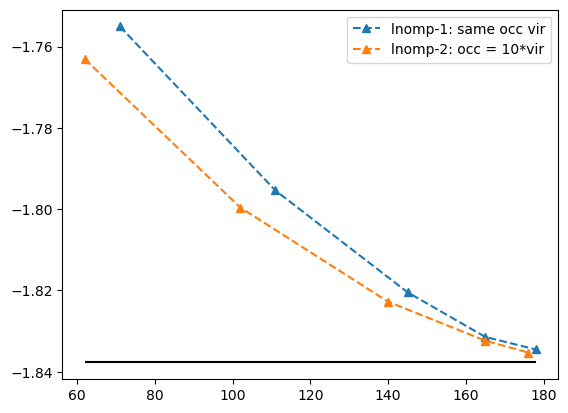

In [35]:
print(size1)
print(emp1)
print(size2)
print(emp2)
from matplotlib import pyplot as plt
plt.plot(size1, emp1, "^--", color="C0", label="lnomp-1: same occ vir")
plt.plot(size2, emp2, "^--", color="C1", label="lnomp-2: occ = 10*vir")
plt.hlines(mymp.e_corr, xmin=min(np.hstack((size1,size2))), xmax=max(np.hstack((size1,size2))), colors='k')
plt.legend()
plt.show()